In [ ]:
# Final Year Project - Deepfake Detection Using Vision Transoformers

!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
################################### IMPORTS ###################################
import torch # using PyTorch
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms # for data augmentation
from torchvision.transforms import v2 # also for augmentation
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from IPython.display import Image
from torchvision import datasets
from transformers import AutoImageProcessor
from torch import nn
from torch.nn import Module, ModuleList
import math
# for training
import time
from transformers import TrainingArguments
from transformers import Trainer as Trainer1 #helps avoid confusion between methods 1 and 2
import time #for measuring duration of training methods
from sklearn.metrics import accuracy_score #method 1
from google.colab import drive # for CUDA
drive.mount('/content/drive', force_remount=True)
import evaluate
from transformers import ViTForImageClassification
from transformers import DeiTForImageClassificationWithTeacher
from transformers import CvtForImageClassification
#for Colab repository
import shutil
import zipfile
import os
import gc
# confusion matrices + metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



Mounted at /content/drive


In [ ]:
################################ L0CAL DATASET #################################
# speeds up image fetching, instead of fetching from Drive each new session
#A7

# copying existing zip Dataset file to speed up image fetching process
print(f"Copying zip folder from drive to local colab storage")
!cp "/content/drive/My Drive/Colab Notebooks/FinalProject/Dataset.zip" /content/Dataset.zip

print(f"Copied. Now unzipping the folder")
!unzip -q /content/Dataset.zip -d /content/Dataset #q = Quiet so it doesnt print out each image name
print(f"Unzipped.")

# checking amounts of images loaded in
# find -type f looks for every single file
# wc - l = Word Count - Lines , counts the lines and prints as a nr instead of individual img names
print(f"Amount of train images in local storage: (should be 140002)")
!find /content/Dataset/Train -type f | wc -l

print(f"Amount of val images in local storage: (should be 39428)")
!find /content/Dataset/Validation -type f | wc -l

print(f"Amount of test images in local storage: (should be 10905)")
!find /content/Dataset/Test -type f | wc -l

# deleting zip file from local storage while keeping unzipped Dataset
# to take back 1.68 GB of disk space
!rm /content/Dataset.zip

Copying zip folder from drive to local colab storage
Copied. Now unzipping the folder
Unzipped.
Amount of train images in local storage: (should be 140002)
140002
Amount of val images in local storage: (should be 39428)
39428
Amount of test images in local storage: (should be 10905)
10905


In [ ]:
################################ CONFIGURATION #################################

config = {
    "image_size": 72,
    "patch_size": 6,
    "dim": 192,
    "nr_channels": 3,
    "nr_layers": 4,
    "nr_heads": 12,
    "nr_classes": 2, # real or fake
    "dropout": 0.1,
    "r_mlp": 4,
}

################################ TRAINING ARGS #################################

train_args = {
    "learning_rate": 0.0003,
    "weight_decay": 0.01,
    "batch_size":  256,
    "epochs" : 70,
    "num_workers": 8, #2 cores from colab free, 12 for paid L4/a100
    "pin_memory": True
}

In [ ]:
################################## DATA PATHS ##################################
#base_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Dataset" # path to my drive
base_path = "/content/Dataset" # path to local data

#train, test, val data paths # # ~ 190.3k otal
train_path = base_path + "/Train" #~140k (~70k real, ~70k fake)
val_path = base_path + "/Validation" #~39.4k (~19700 real, -//- fake)
test_path = base_path + "/Test" #~10.9k (~5450 real, -//- fake)

############################## DATA AUGMENTATION ###############################

# https://docs.pytorch.org/vision/0.22/transforms.html
# recommended by pytorch for Image Classification
# additions from https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb

train_transforms = v2.Compose([
    v2.ToImage(), # needed only if PIL image
    v2.Resize((config["image_size"], config["image_size"])),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#pre-trained models since they expect 224 images
pt_train_transforms = v2.Compose([
    v2.ToImage(), # needed only if PIL image
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

pt_val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

pt_test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

################################# LOADING DATA #################################
# https://stackoverflow.com/questions/75319061/how-to-get-the-filenames-of-misclassified-images-in-the-test-data-set-pytorch

# allows to return image, label and PATH (needed to know exactly which images were misclassified by models for later comparisons/patterns)
class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super(ImageFolderWithPaths, self).__getitem__(index) #A7
        path = self.imgs[index][0]
        return img, label, path

# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb
# Load data
train_data = ImageFolderWithPaths(train_path, train_transforms)
val_data = ImageFolderWithPaths(val_path, val_transforms)
test_data = ImageFolderWithPaths(test_path, test_transforms)

pt_train_data = ImageFolderWithPaths(train_path, pt_train_transforms)
pt_val_data = ImageFolderWithPaths(val_path, pt_val_transforms)
pt_test_data = ImageFolderWithPaths(test_path, pt_test_transforms)

dataloaders = {
    "train": DataLoader(train_data, batch_size=train_args["batch_size"], shuffle=True, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"]),
    "val": DataLoader(val_data, batch_size=train_args["batch_size"], shuffle=False, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"]),
    "test": DataLoader(test_data, batch_size=train_args["batch_size"], shuffle=False, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"])
}

pt_dataloaders = {
    "train": DataLoader(pt_train_data, batch_size=train_args["batch_size"], shuffle=True, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"]),
    "val": DataLoader(pt_val_data, batch_size=train_args["batch_size"], shuffle=False, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"]),
    "test": DataLoader(pt_test_data, batch_size=train_args["batch_size"], shuffle=False, num_workers=train_args["num_workers"], pin_memory=train_args["pin_memory"])
}

dataset_sizes = {
    "train": len(train_data),
    "val": len(val_data),
    "test": len(test_data)
}
class_names = train_data.classes

#pirnting info
print(f"Classes: {class_names}")
print() # separating for nicer print display

print(f"Train dataset size: {dataset_sizes["train"]}")
print(f"Validation dataset size: {dataset_sizes["val"]}")
print(f"Test dataset size: {dataset_sizes["test"]}")

#printing pt info to make sure it matches
print()
print(f"Pre-trained Train dataset size: {len(pt_train_data)}")
print(f"Pre-trained Validation dataset size: {len(pt_val_data)}")
print(f"Pre-trained Test dataset size: {len(pt_test_data)}")

Classes: ['Fake', 'Real']

Train dataset size: 140002
Validation dataset size: 39428
Test dataset size: 10905

Pre-trained Train dataset size: 140002
Pre-trained Validation dataset size: 39428
Pre-trained Test dataset size: 10905


In [ ]:
################################## ViT MODEL ###################################

# patch embedding
class PatchEmbeddings(Module):
    #converting images into patches

    def __init__(self, config):
        super().__init__()
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.emb_dim = config["dim"]
        self.nr_channels = config["nr_channels"]

        self.nr_patches = (self.image_size // self.patch_size) ** 2

        # conv with kernel , stride, patch size equal slices and projects
        self.project = nn.Conv2d(self.nr_channels, self.emb_dim, kernel_size=self.patch_size, stride=self.patch_size)


    def forward(self, x):
        #batch size, channels, img height, img width > b, emb_dim, patch col, patch row
        x = self.project(x)

        # b, emb_dim, patch col, patch row > b, emb_dim, nr_patches
        x = x.flatten(2)

        #b, dim, patch > b, nr_patches, emb_dim
        x = x.transpose(1,2)

        return x


#positional encoding and class token
class PositionalEmbeddings(Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embeddings = PatchEmbeddings(config)
        nr_patches = (config["image_size"] // config["patch_size"]) ** 2

        # creating classification token
        self.cls_token = nn.Parameter(torch.randn(1, 1, config["dim"]))

        # position emb for the csl token and patches
        self.position_emb = nn.Parameter(torch.randn(1, nr_patches + 1, config["dim"]));

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embeddings(x)

        # expanding tokens
        tokens = self.cls_token.expand(B, -1, -1)
        # concatenate token to start of patches
        x = torch.cat((tokens, x), dim = 1)

        # adding positional encoding to embeddins before being outputted
        x = x + self.position_emb
        return x

#single attention head
class Attention(Module):
    #global relationships between patches

    def __init__(self, config, head_size):
        super().__init__()
        self.head_size = head_size
        self.dim = config["dim"]
        self.dropout = nn.Dropout(config["dropout"]) #dropout used to prevent overfitting

        self.key = nn.Linear(self.dim, self.head_size)
        self.val = nn.Linear(self.dim, self.head_size)
        self.query = nn.Linear(self.dim, self.head_size)

    def forward(self, x):
        key = self.key(x)
        val = self.val(x)
        query = self.query(x)

        # score = how similar the patch is to other pathces
        # probs = scores but changed to weights
        # output = final result of each head, basically a weighted average of info

        attn_scores = (torch.matmul(query, key.transpose(-1,-2))) / math.sqrt(self.head_size)
        attn_probs = nn.functional.softmax(attn_scores, dim = -1)
        attn_probs = self.dropout(attn_probs)
        output = torch.matmul(attn_probs, val)
        return (output, attn_probs)

class MultiHeadAttention(Module):
    # parallel attention heads
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.nr_heads = config["nr_heads"]
        self.head_size = self.dim // self.nr_heads
        self.heads = nn.ModuleList([Attention(config, self.head_size) for _ in range(self.nr_heads)])

        self.to_out = nn.Linear(self.dim, self.dim)

    def forward(self, x):
        out = torch.cat([head(x)[0] for head in self.heads], dim = -1) # 0 gives output, 1 gives probs
        output = self.to_out(out)
        return output


# Multilayer Perceptron / Feed forward Network
class MLP(Module):
    #intorduces non-linearity and for learning complex features
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.dropout = config["dropout"]
        self.r_mlp = config["r_mlp"]
        hidden_dim = self.dim * self.r_mlp
        self.mlp = nn.Sequential(
            nn.Linear(self.dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_dim, self.dim),
            nn.Dropout(self.dropout)
        )


    def forward(self,x):
        output= self.mlp(x)
        return output


# transofmrer encoder blocks
class Encoder(Module):

    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]

        #layer normalisation
        self.norm1 = nn.LayerNorm(self.dim)
        self.norm2 = nn.LayerNorm(self.dim)
        # multi-head attention
        self.mha = MultiHeadAttention(config)
        # multi layer perception
        self.mlp = MLP(config)


    def forward(self, x):
        x = x + self.mha(self.norm1(x)) # after sublayer 1
        output = x + self.mlp(self.norm2(x)) #after sublayer 2
        return output

#classification head
class ViTForClassification(Module):

    def __init__(self,config):
        super().__init__()

        # following config build
        self.dim = config["dim"]
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.nr_heads = config["nr_heads"]
        self.nr_channels = config["nr_channels"]
        self.nr_classes = config["nr_classes"]
        self.dropout = config["dropout"]
        self.loss_fn = nn.CrossEntropyLoss()

        #going through each class
        self.positional_emb = PositionalEmbeddings(config)
        self.encoders = nn.ModuleList([Encoder(config) for _ in range(config["nr_layers"])])
        self.norm = nn.LayerNorm(self.dim)
        # projects encoder output to nr of target classes
        self.classifier = nn.Linear(self.dim, self.nr_classes)

#https://huggingface.co/docs/transformers/v4.27.0/en/main_classes/trainer
    def forward(self, img, labels=None):
        #now running data through each class
        x = self.positional_emb(img) #positional and patch emb
        for layer in self.encoders:
            x = layer(x)

        x = self.norm(x)
        output = self.classifier(x[:, 0])

        #A7
        loss = None
        if labels is not None: #for training method 1
            loss = self.loss_fn(output, labels)
            return (loss, output)

        return output


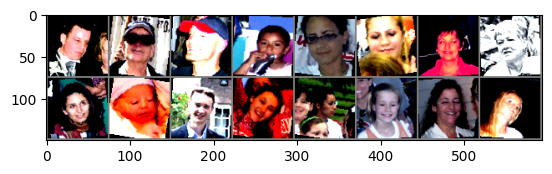

Labels:  Fake | Fake | Fake | Real | Fake | Fake | Real | Real | Real | Fake | Real | Fake | Real | Fake | Fake | Real


In [ ]:
################################### FULL RUNS ##################################

# https://stackoverflow.com/questions/59005242/how-to-get-n-number-of-images-from-torchvision-datasets-imagefolder
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html


#dataset = torchvision.datasets.ImageFolder(...)
np.random.seed(42) # for fair comparisons

def imshow(img):
    # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    img = img / 2 + 0.5     # unnormalize, tho not fully so colours will be slightly off (but this is insignificant for a small scale run)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(dataloaders["train"])
images, labels, paths = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:16])) # showing only 16 images for display
# print labels
print('Labels: ', ' | '.join(f'{class_names[labels[j]]}' for j in range(16)))

In [ ]:
################################### TRAINING ###################################

device = "cuda"if torch.cuda.is_available() else "cpu"
print(device)

criterion = nn.CrossEntropyLoss().to(device)

#method three
# https://github.com/pytorch/examples/blob/main/imagenet/main.py
class AverageMeter(object):
    def __init__(self, name):
        self.name = name
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target):
    with torch.no_grad():
        batch_size = target.size(0)
        _, pred = output.topk(1, 1, True, True)
        pred = pred.t()

        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
        res= correct_1.mul_(100.0 / batch_size)
        return res


def train(train_loader, model, criterion, optimizer, device):
    losses = AverageMeter("Loss")

    # switch to train mode
    model.train()

    start = time.time()
    for i, (images, target, _) in enumerate(train_loader):

        if i % 100 == 0:
          print(f"Batch {i}")

        # move data to the same device as model
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # compute output
        output = model(images)
        # A7 - extract logits, crashes otherwise since huggingface models dont return tensors
        if hasattr(output, 'logits'):
          output = output.logits
        loss = criterion(output, target)

        #record loss
        losses.update(loss.item(), images.size(0))

        # compute gradient and do SGD step
        optimizer.zero_grad() #clearing old gradients
        loss.backward() #new gradients
        optimizer.step() #updating weights

    return losses.avg


def validate(valloader, model, criterion, device):
    model.eval()
    losses = AverageMeter("Loss")
    acc = AverageMeter("Accuracy")

    model.eval()

    with torch.no_grad():
        for i, (images, target, _) in enumerate(valloader):

            if i % 50 == 0:
              print(f"Batch {i}")


            images = images.to(device)
            target = target.to(device)

            output = model(images)
            if hasattr(output, 'logits'):
              output = output.logits
            loss = criterion(output, target)

            #calculating accuracy for method comparison
            acc1 = accuracy(output, target).item()

            losses.update(loss.item(), images.size(0))
            acc.update(acc1, images.size(0))

    return losses.avg, acc.avg



#avg loss from https://github.com/aidendorian/Vision-Transformer-for-DeepFake-Detection/blob/master/pre_training.py


cuda


In [ ]:
################################### OWN MODEL ###################################

torch.manual_seed(42)

checkpoint_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_mine.pt" #saving pt file for each run incase of timeouts/interuptions
best_acc_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_mine_BestAcc.pt" #saving epoch info when best accuracy is achieved


model = ViTForClassification(config).to(device)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])

train_losses = []
val_losses = []

start_time = time.time()
best_acc = 0
start_epoch = 0 # for checkpointing

for epoch in range(start_epoch, train_args["epochs"]):
    e_start_time = time.time()
    #main runs
    train_loss = train(dataloaders["train"], model, criterion, optimizer,device)
    val_loss, acc = validate(dataloaders["val"],model, criterion, device)
    e_end_time = time.time()

    #for loss curves
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    #https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/dbcf5e6a5e95bf9f7a0e49e123c13b60/saving_and_loading_a_general_checkpoint.ipynb#scrollTo=GZZi4Al2lt4H
    #creating checkpoint at each epoch incase of Colab "timeout"
    torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_acc": best_acc,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "config": config,
                "train_args": train_args
                }, checkpoint_path )

    # saving checkpoint when best accuracy occurs during run
    if acc > best_acc:
      best_acc = acc
      torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_acc": best_acc,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "config": config,
                "train_args": train_args
      }, best_acc_path)


    if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"Own Model: Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%,  Highest Accuracy: {best_acc:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")

Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Own Model: Epoch: 1, Time: 78.59s, Train loss: 0.5054, Validation loss: 0.4936,  Accuracy: 75.81%,  Highest Accuracy: 75.81%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Own Model: Epoch: 5, Time: 77.40s, Train loss: 0.3153, Validation loss: 0.3294,  Accuracy: 84.56%,  Highest Accuracy: 84.56%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100


In [ ]:
########################## GETTING ALL PREDICTIONS #############################
# https://stackoverflow.com/questions/48264368/save-predictions-from-pytorch-model +
# https://discuss.pytorch.org/t/saving-the-predictions-to-csv/155806 +
#https://discuss.pytorch.org/t/viewing-misclassified-image-predictions/82410/7 (Nishant_Bhansali)

preds_checkpoints = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/"

def get_model_preds(model, dataloader, device,modelname):
  model.eval()
  preds = []

  with torch.no_grad(): #A7 only no_Grad
    for images, labels, paths in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      if hasattr(outputs, 'logits'):
        outputs = outputs.logits

      #a7
      probs = torch.nn.functional.softmax(outputs, dim=1) #softmax for numbers to probabilities
      _, predicted = torch.max(outputs, 1)

      for i in range(len(labels)):
        preds.append({
            "path": paths[i],
            "label": labels[i].item(),
            "prediction": predicted[i].item(),
            "correct": bool(labels[i].item() == predicted[i].item()),
            "prob_fake": probs[i][0].item(), # checking level of confidence in its classification
            "prob_real": probs[i][1].item()
        })

  #saving to csv file for analysis later
  df = pd.DataFrame(preds)
  preds_path = f"{preds_checkpoints}{modelname}_predictions.csv"
  df.to_csv(preds_path, index=False)
  print(f"Saved {len(df)} rows to {modelname}_predictions.csv") #checking that all predictions managed to save to the file
  return df



In [ ]:
best_checkpoint = torch.load(best_acc_path)
model.load_state_dict(best_checkpoint['model_state_dict'])
print(f"Own Model: Best epoch: {best_checkpoint['epoch']+1}, Accuracy: {best_checkpoint['best_acc']:.2f}%")
df_Mine = get_model_preds(model, dataloaders["test"], device, "MyVit")


Own Model: Best epoch: 64, Accuracy: 94.04%
Saved 10905 rows to MyVit_predictions.csv


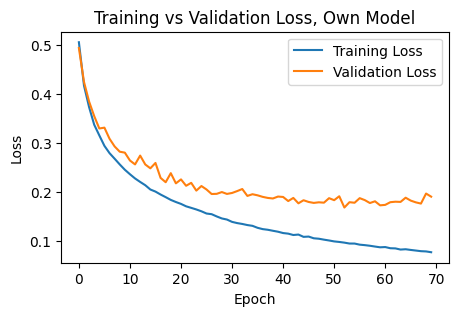

In [ ]:
# plotting losses from own model
plt.figure(figsize=(5,3))
plt.title("Training vs Validation Loss, Own Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()

In [ ]:
############################## PRE-TRAINED MODEL 1 ##############################

# vit_b_16 from huggingface
# https://huggingface.co/google/vit-base-patch16-224
# https://huggingface.co/blog/fine-tune-vit

torch.cuda.empty_cache() #taking back some system memory


torch.manual_seed(42)

checkpoint_path1 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_vit_b_16.pt" #saving pt file for each run incase of timeouts/interuptions
best_acc_path1 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_vit_b_16_BestAcc.pt" #saving epoch info when best accuracy is achieved


model1 = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224', num_labels=2,ignore_mismatched_sizes=True)
model1 = model1.to(device)

optimizer1 = torch.optim.AdamW(model1.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])

train_losses1 = []
val_losses1 = []
best_acc1 = 0
start_epoch = 0 # for checkpointing

start_time = time.time()
for epoch in range(start_epoch, train_args["epochs"]):
    e_start_time = time.time()
    #main runs
    train_loss = train(pt_dataloaders["train"], model1, criterion, optimizer1,device)
    val_loss, acc = validate(pt_dataloaders["val"],model1, criterion, device)
    e_end_time = time.time()

    #for loss curves
    train_losses1.append(train_loss)
    val_losses1.append(val_loss)

    #https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/dbcf5e6a5e95bf9f7a0e49e123c13b60/saving_and_loading_a_general_checkpoint.ipynb#scrollTo=GZZi4Al2lt4H
    #creating checkpoint at each epoch incase of Colab "timeout"
    torch.save({
                "epoch": epoch,
                "model_state_dict": model1.state_dict(),
                "optimizer_state_dict": optimizer1.state_dict(),
                "best_acc": best_acc1,
                "train_losses": train_losses1,
                "val_losses": val_losses1,
                "train_args": train_args #config deleted since the model uses its own settings
                }, checkpoint_path1 )

    # saving checkpoint when best accuracy occurs during run
    if acc > best_acc1:
      best_acc1 = acc
      torch.save({
                "epoch": epoch,
                "model_state_dict": model1.state_dict(),
                "optimizer_state_dict": optimizer1.state_dict(),
                "best_acc": best_acc1,
                "train_losses": train_losses1,
                "val_losses": val_losses1,
                "train_args": train_args
      }, best_acc_path1)


    if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"ViT_B_16: Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%,  Highest Accuracy: {best_acc1:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
ViT_B_16: Epoch: 1, Time: 958.00s, Train loss: 0.1098, Validation loss: 0.1268,  Accuracy: 95.03%,  Highest Accuracy: 95.03%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
ViT_B_16: Epoch: 5, Time: 954.16s, Train loss: 0.0400, Validation loss: 0.0775,  Accuracy: 97.59%,  Highest Accuracy: 97.81%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100


KeyboardInterrupt: 

In [ ]:
# RUN "GETTING ALL PREDICTIONS" CELL AGAIN

In [ ]:
best_checkpoint = torch.load(best_acc_path1)
model1.load_state_dict(best_checkpoint['model_state_dict'])
print(f"ViT_B_16: Best epoch: {best_checkpoint['epoch']+1}, Accuracy: {best_checkpoint['best_acc']:.2f}%")
df_1 = get_model_preds(model1, pt_dataloaders["test"], device, "ViT_B_16")

ViT_B_16: Best epoch: 30, Accuracy: 98.22%
Saved 10905 rows to ViT_B_16_predictions.csv


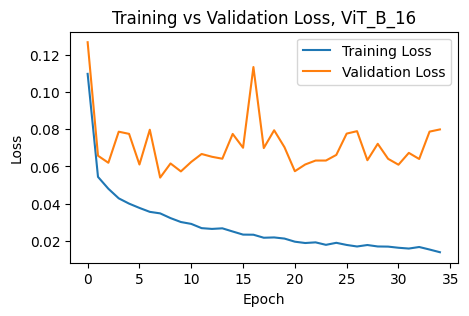

In [ ]:
# plotting losses from Pre-trained Model 1
plt.figure(figsize=(5,3))
plt.title("Training vs Validation Loss, ViT_B_16")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses1, label="Training Loss")
plt.plot(val_losses1, label="Validation Loss")
plt.legend()
plt.show()

In [ ]:
############################## PRE-TRAINED MODEL 2 ##############################

# DeiT-Tiny
# https://huggingface.co/facebook/deit-tiny-distilled-patch16-224

del model1
torch.cuda.empty_cache() #taking back some system memory
torch.manual_seed(42)

checkpoint_path2 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_pt2.pt" #saving pt file for each run incase of timeouts/interuptions
best_acc_path2 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_pt2_BestAcc.pt" #saving epoch info when best accuracy is achieved

model2 = DeiTForImageClassificationWithTeacher.from_pretrained('facebook/deit-tiny-distilled-patch16-224', num_labels=2,ignore_mismatched_sizes=True)
model2 = model2.to(device)

optimizer2 = torch.optim.AdamW(model2.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])

train_losses2 = []
val_losses2 = []
best_acc2 = 0
start_epoch = 0 # for checkpointing

start_time = time.time()
for epoch in range(start_epoch, train_args["epochs"]):
    e_start_time = time.time()
    #main runs
    train_loss = train(pt_dataloaders["train"], model2, criterion, optimizer2, device)
    val_loss, acc = validate(pt_dataloaders["val"],model2, criterion, device)
    e_end_time = time.time()

    #for loss curves
    train_losses2.append(train_loss)
    val_losses2.append(val_loss)

    #https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/dbcf5e6a5e95bf9f7a0e49e123c13b60/saving_and_loading_a_general_checkpoint.ipynb#scrollTo=GZZi4Al2lt4H
    #creating checkpoint at each epoch incase of Colab "timeout"
    torch.save({
                "epoch": epoch,
                "model_state_dict": model2.state_dict(),
                "optimizer_state_dict": optimizer2.state_dict(),
                "best_acc": best_acc2,
                "train_losses": train_losses2,
                "val_losses": val_losses2,
                "train_args": train_args
                }, checkpoint_path2 )

    # saving checkpoint when best accuracy occurs during run
    if acc > best_acc2:
      best_acc2 = acc
      torch.save({
                "epoch": epoch,
                "model_state_dict": model2.state_dict(),
                "optimizer_state_dict": optimizer2.state_dict(),
                "best_acc": best_acc2,
                "train_losses": train_losses2,
                "val_losses": val_losses2,
                "train_args": train_args
      }, best_acc_path2)


    if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"DeiT-Tiny: Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%,  Highest Accuracy: {best_acc2:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

DeiTForImageClassificationWithTeacher LOAD REPORT from: facebook/deit-tiny-distilled-patch16-224
Key                            | Status   |                                                                                        
-------------------------------+----------+----------------------------------------------------------------------------------------
cls_classifier.weight          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 192]) vs model:torch.Size([2, 192])
cls_classifier.bias            | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 192]) vs model:torch.Size([2, 192])
distillation_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
DeiT-Tiny: Epoch: 1, Time: 158.44s, Train loss: 0.1646, Validation loss: 0.1004,  Accuracy: 96.03%,  Highest Accuracy: 96.03%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
DeiT-Tiny: Epoch: 5, Time: 158.13s, Train loss: 0.0582, Validation loss: 0.0996,  Accuracy: 96.04%,  Highest Accuracy: 97.05%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 10

KeyboardInterrupt: 

In [ ]:
# RUN "GETTING ALL PREDICTIONS" CELL AGAIN

In [ ]:
best_checkpoint = torch.load(best_acc_path2)
model2.load_state_dict(best_checkpoint['model_state_dict'])
print(f"DeiT-Tiny: Best epoch: {best_checkpoint['epoch']+1}, Accuracy: {best_checkpoint['best_acc']:.2f}%")
df_2 = get_model_preds(model2, pt_dataloaders["test"], device, "DeiT-Tiny")

DeiT-Tiny: Best epoch: 29, Accuracy: 98.01%
Saved 10905 rows to DeiT-Tiny_predictions.csv


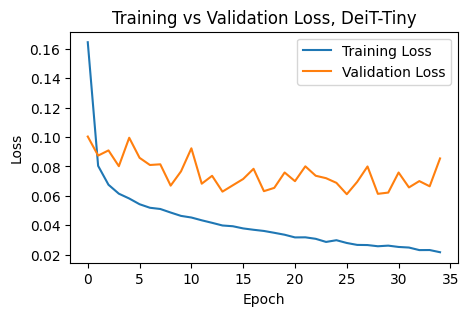

In [ ]:
# plotting losses from Pre-trained Model 2
plt.figure(figsize=(5,3))
plt.title("Training vs Validation Loss, DeiT-Tiny")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses2, label="Training Loss")
plt.plot(val_losses2, label="Validation Loss")
plt.legend()
plt.show()

In [ ]:
############################## PRE-TRAINED MODEL 3 ##############################

torch.cuda.empty_cache() #taking back some system memory
torch.manual_seed(42)

# CvT-13
# https://huggingface.co/microsoft/cvt-13

checkpoint_path3 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_CvT-13.pt" #saving pt file for each run incase of timeouts/interuptions
best_acc_path3 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_CvT-13_BestAcc.pt" #saving epoch info when best accuracy is achieved

model3 = CvtForImageClassification.from_pretrained('microsoft/cvt-13', num_labels=2, ignore_mismatched_sizes=True)
model3 = model3.to(device)

optimizer3 = torch.optim.AdamW(model3.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])

train_losses3 = []
val_losses3 = []
best_acc3 = 0
start_epoch = 0 # for checkpointing

start_time = time.time()
for epoch in range(start_epoch, train_args["epochs"]):
    e_start_time = time.time()
    #main runs
    train_loss = train(pt_dataloaders["train"], model3, criterion, optimizer3, device)
    val_loss, acc = validate(pt_dataloaders["val"],model3, criterion, device)
    e_end_time = time.time()

    #for loss curves
    train_losses3.append(train_loss)
    val_losses3.append(val_loss)

    #https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/dbcf5e6a5e95bf9f7a0e49e123c13b60/saving_and_loading_a_general_checkpoint.ipynb#scrollTo=GZZi4Al2lt4H
    #creating checkpoint at each epoch incase of Colab "timeout"
    torch.save({
                "epoch": epoch,
                "model_state_dict": model3.state_dict(),
                "optimizer_state_dict": optimizer3.state_dict(),
                "best_acc": best_acc3,
                "train_losses": train_losses3,
                "val_losses": val_losses3,
                "train_args": train_args
                }, checkpoint_path3 )

    # saving checkpoint when best accuracy occurs during run
    if acc > best_acc3:
      best_acc3 = acc
      torch.save({
                "epoch": epoch,
                "model_state_dict": model3.state_dict(),
                "optimizer_state_dict": optimizer3.state_dict(),
                "best_acc": best_acc3,
                "train_losses": train_losses3,
                "val_losses": val_losses3,
                "train_args": train_args
      }, best_acc_path3)


    if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"CvT-13: Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%,  Highest Accuracy: {best_acc3:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
CvT-13: Epoch: 1, Time: 393.60s, Train loss: 0.2147, Validation loss: 0.1292,  Accuracy: 95.32%,  Highest Accuracy: 95.32%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
CvT-13: Epoch: 5, Time: 379.28s, Train loss: 0.1646, Validation loss: 0.0829,  Accuracy: 96.77%,  Highest Accuracy: 98.29%
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batch 150
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 0
Batch 50
Batch 100
Batc

KeyboardInterrupt: 

In [ ]:
# RUN "GETTING ALL PREDICTIONS" CELL AGAIN

In [ ]:
best_checkpoint = torch.load(best_acc_path3)
model3.load_state_dict(best_checkpoint['model_state_dict'])
print(f"CvT-13: Best epoch: {best_checkpoint['epoch']+1}, Accuracy: {best_checkpoint['best_acc']:.2f}%")
df_3 = get_model_preds(model3, pt_dataloaders["test"], device, "CvT-13")

CvT-13: Best epoch: 32, Accuracy: 98.71%
Saved 10905 rows to CvT-13_predictions.csv


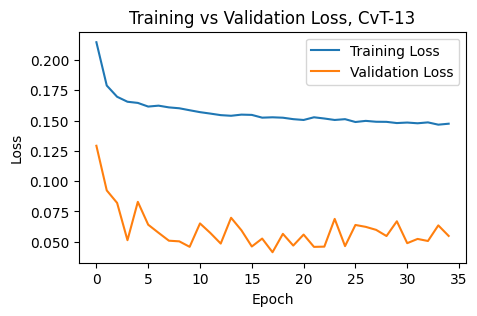

In [ ]:
# plotting losses from Pre-trained Model 3
plt.figure(figsize=(5,3))
plt.title("Training vs Validation Loss, CvT-13")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses3, label="Training Loss")
plt.plot(val_losses3, label="Validation Loss")
plt.legend()
plt.show()

In [ ]:
################################ LOAD CHECKPOINT ###############################

# OWN MODEL

# for loading from checkpoint if timed out
#checkpoint = torch.load(checkpoint_path)
#model.load_state_dict(checkpoint['model_state_dict'])
#optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#start_epoch = checkpoint["epoch"] + 1
#best_acc = checkpoint["best_acc"]
#train_losses = checkpoint["train_losses"]
#val_losses = checkpoint["val_losses"]


# Model 1 - vit b 16

# for loading from checkpoint if timed out
#checkpoint = torch.load(checkpoint_path1)
#model1.load_state_dict(checkpoint['model_state_dict'])
#optimizer1.load_state_dict(checkpoint['optimizer_state_dict'])
#start_epoch = checkpoint["epoch"] + 1
#best_acc1 = checkpoint["best_acc"]
#train_losses1 = checkpoint["train_losses"]
#val_losses1 = checkpoint["val_losses"]



# Model 2 - DeiT-Tiny

# for loading from checkpoint if timed out
#checkpoint = torch.load(checkpoint_path2)
#model2.load_state_dict(checkpoint['model_state_dict'])
#optimizer2.load_state_dict(checkpoint['optimizer_state_dict'])
#start_epoch = checkpoint["epoch"] + 1
#best_acc2 = checkpoint["best_acc"]
#train_losses2 = checkpoint["train_losses"]
#val_losses2 = checkpoint["val_losses"]



# Model 3 - CvT-13

#checkpoint = torch.load(checkpoint_path3 )
#model3.load_state_dict(checkpoint['model_state_dict'])
#optimizer3.load_state_dict(checkpoint['optimizer_state_dict'])
#start_epoch = checkpoint["epoch"] + 1
#best_acc3 = checkpoint["best_acc"]
#train_losses3 = checkpoint["train_losses"]
#val_losses3 = checkpoint["val_losses"]

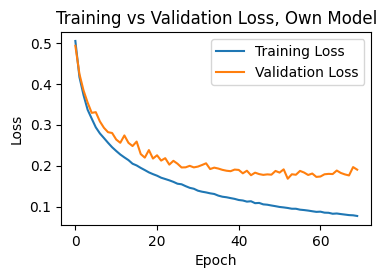

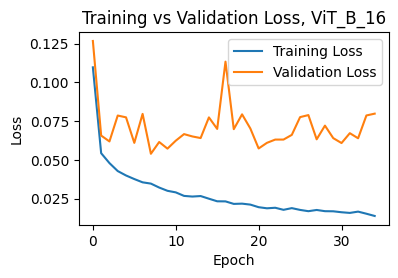

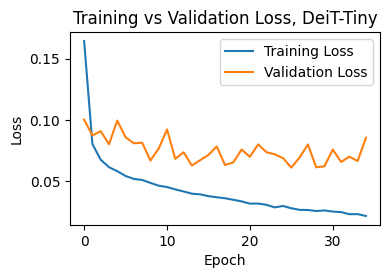

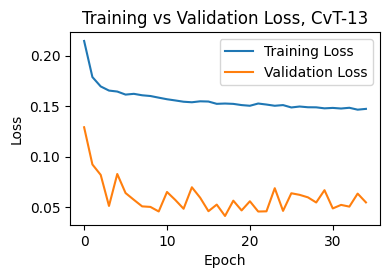

In [ ]:
################################### LOSS CURVES ##################################
#https://www.geeksforgeeks.org/deep-learning/training-and-validation-loss-in-deep-learning/

checkpoint_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_mine.pt"
checkpoint_path1 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_vit_b_16.pt" #saving pt file for each run incase of timeouts/interuptions
checkpoint_path2 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_pt2.pt"
checkpoint_path3 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_CvT-13.pt"

#loading train losses from checkpoints
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
checkpoint1 = torch.load(checkpoint_path1, map_location=torch.device('cpu'))
checkpoint2 = torch.load(checkpoint_path2, map_location=torch.device('cpu'))
checkpoint3 = torch.load(checkpoint_path3,map_location=torch.device('cpu') )

# loading losses from corresponding checkpoints
train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

train_losses1 = checkpoint1["train_losses"]
val_losses1 = checkpoint1["val_losses"]

train_losses2 = checkpoint2["train_losses"]
val_losses2 = checkpoint2["val_losses"]

train_losses3 = checkpoint3["train_losses"]
val_losses3 = checkpoint3["val_losses"]

# plotting losses from own model
plt.figure(figsize=(4,2.5))
plt.title("Training vs Validation Loss, Own Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()

# plotting losses from Pre-trained Model 1
plt.figure(figsize=(4,2.5))
plt.title("Training vs Validation Loss, ViT_B_16")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses1, label="Training Loss")
plt.plot(val_losses1, label="Validation Loss")
plt.legend()
plt.show()

# plotting losses from Pre-trained Model 2
plt.figure(figsize=(4,2.5))
plt.title("Training vs Validation Loss, DeiT-Tiny")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses2, label="Training Loss")
plt.plot(val_losses2, label="Validation Loss")
plt.legend()
plt.show()

# plotting losses from Pre-trained Model 3
plt.figure(figsize=(4,2.5))
plt.title("Training vs Validation Loss, CvT-13")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses3, label="Training Loss")
plt.plot(val_losses3, label="Validation Loss")
plt.legend()
plt.show()


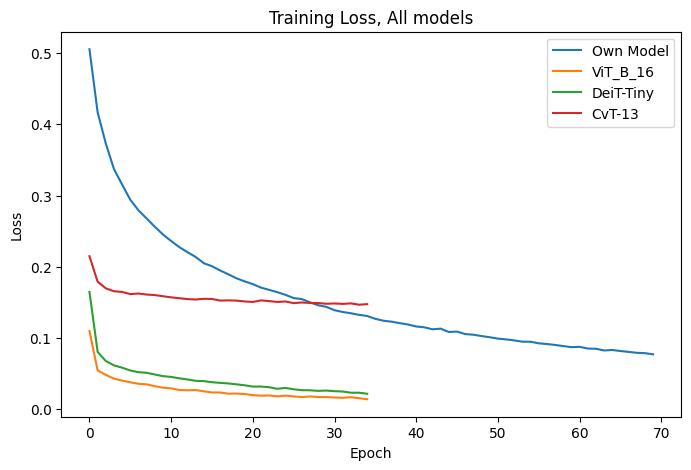

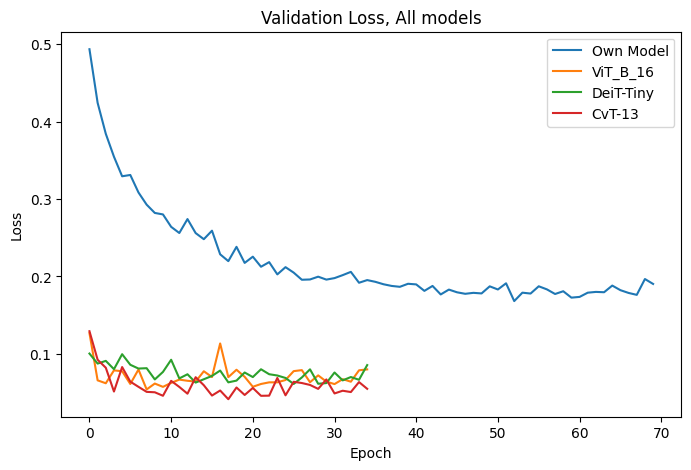

In [ ]:
# all train losses
plt.figure(figsize=(8,5))
plt.title("Training Loss, All models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses, label="Own Model")
plt.plot(train_losses1, label="ViT_B_16")
plt.plot(train_losses2, label="DeiT-Tiny")
plt.plot(train_losses3, label="CvT-13")
plt.legend()
plt.show()

print()
# all val losses
plt.figure(figsize=(8,5))
plt.title("Validation Loss, All models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(val_losses, label="Own Model")
plt.plot(val_losses1, label="ViT_B_16")
plt.plot(val_losses2, label="DeiT-Tiny")
plt.plot(val_losses3, label="CvT-13")
plt.legend()
plt.show()

In [ ]:
################################ BEST OF MODELS ################################
# getting prediction results for all models when each achieved best acc
# loading in the results for models when they achieved best acc each
best_checkpoint = torch.load(best_acc_path, map_location=torch.device('cpu'))
best_checkpoint1 = torch.load(best_acc_path1, map_location=torch.device('cpu'))
best_checkpoint2 = torch.load(best_acc_path2, map_location=torch.device('cpu'))
best_checkpoint3 = torch.load(best_acc_path3, map_location=torch.device('cpu'))

model.load_state_dict(best_checkpoint['model_state_dict'])
model1.load_state_dict(best_checkpoint1['model_state_dict'])
model2.load_state_dict(best_checkpoint2['model_state_dict'])
model3.load_state_dict(best_checkpoint3['model_state_dict'])

print(f"Own Model: Best epoch: {best_checkpoint['epoch']+1}, Accuracy: {best_checkpoint['best_acc']:.2f}%")
print(f"ViT_B_16: Best epoch: {best_checkpoint1['epoch']+1}, Accuracy: {best_checkpoint1['best_acc']:.2f}%")
print(f"DeiT-Tiny: Best epoch: {best_checkpoint2['epoch']+1}, Accuracy: {best_checkpoint2['best_acc']:.2f}%")
print(f"CvT-13: Best epoch: {best_checkpoint3['epoch']+1}, Accuracy: {best_checkpoint3['best_acc']:.2f}%")

NameError: name 'get_model_preds' is not defined

In [ ]:
############################# PREDICTIONS OF MODELS ############################
# getting prediction results for all models when each achieved best acc
preds_checkpoints = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/"
class_names = ["Fake", "Real"]

# loading in the results
df_Mine = pd.read_csv(f"{preds_checkpoints}MyVit_predictions.csv")
df_1 = pd.read_csv(f"{preds_checkpoints}ViT_B_16_predictions.csv")
df_2 = pd.read_csv(f"{preds_checkpoints}DeiT-Tiny_predictions.csv")
df_3 = pd.read_csv(f"{preds_checkpoints}CvT-13_predictions.csv")

In [ ]:
############################## PERFORMANCE METRICS #############################
best_acc_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_mine_BestAcc.pt" #saving epoch info when best accuracy is achieved
best_acc_path1 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_vit_b_16_BestAcc.pt" #saving epoch info when best accuracy is achieved
best_acc_path2 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_pt2_BestAcc.pt" #saving epoch info when best accuracy is achieved
best_acc_path3 = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/FullRun_CvT-13_BestAcc.pt" #saving epoch info when best accuracy is achieved

best_checkpoint = torch.load(best_acc_path, map_location=torch.device('cpu'))
best_checkpoint1 = torch.load(best_acc_path1, map_location=torch.device('cpu'))
best_checkpoint2 = torch.load(best_acc_path2, map_location=torch.device('cpu'))
best_checkpoint3 = torch.load(best_acc_path3, map_location=torch.device('cpu'))

print(f"Own Model best epoch: {best_checkpoint['epoch']+1}, Best VAL Accuracy: {best_checkpoint['best_acc']:.2f}%")
print(f"Test Data metrics:")
print(classification_report(df_Mine["label"], df_Mine["prediction"], target_names=class_names,digits=4))
print()
print()
print(f"ViT_B_16 best epoch: {best_checkpoint1['epoch']+1}, Best VAL Accuracy: {best_checkpoint1['best_acc']:.2f}%")
print(f"Test Data metrics:")
print(classification_report(df_1["label"], df_1["prediction"], target_names=class_names,digits=4))
print()
print()
print(f"DeiT-Tiny best epoch: {best_checkpoint2['epoch']+1}, Best VAL Accuracy: {best_checkpoint2['best_acc']:.2f}%")
print(f"Test Data metrics:")
print(classification_report(df_2["label"], df_2["prediction"], target_names=class_names,digits=4))
print()
print()
print(f"CvT-13 best epoch: {best_checkpoint3['epoch']+1}, Best VAL Accuracy: {best_checkpoint3['best_acc']:.2f}%")
print(f"Test Data metrics:")
print(classification_report(df_3["label"], df_3["prediction"], target_names=class_names,digits=4))


Own Model best epoch: 64, Best VAL Accuracy: 94.04%
Test Data metrics:
              precision    recall  f1-score   support

        Fake     0.8795    0.9275    0.9029      5492
        Real     0.9222    0.8711    0.8959      5413

    accuracy                         0.8995     10905
   macro avg     0.9008    0.8993    0.8994     10905
weighted avg     0.9007    0.8995    0.8994     10905



ViT_B_16 best epoch: 30, Best VAL Accuracy: 98.22%
Test Data metrics:
              precision    recall  f1-score   support

        Fake     0.8935    0.9772    0.9335      5492
        Real     0.9745    0.8818    0.9258      5413

    accuracy                         0.9298     10905
   macro avg     0.9340    0.9295    0.9296     10905
weighted avg     0.9337    0.9298    0.9297     10905



DeiT-Tiny best epoch: 29, Best VAL Accuracy: 98.01%
Test Data metrics:
              precision    recall  f1-score   support

        Fake     0.8873    0.9689    0.9263      5492
        Real     0.96

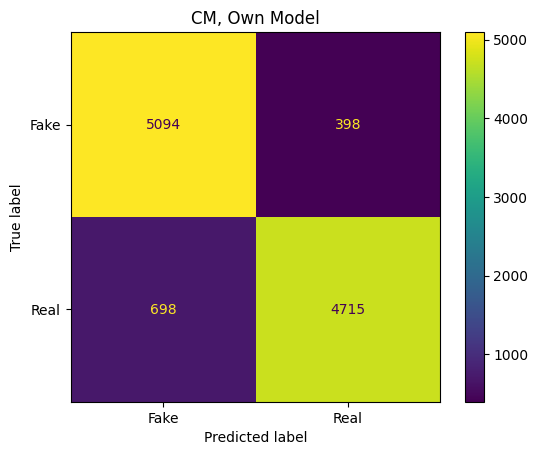

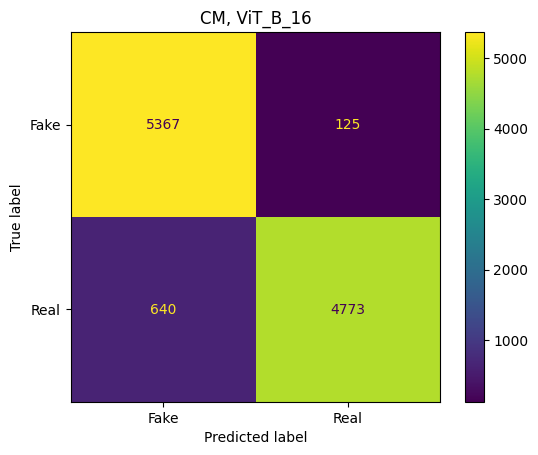

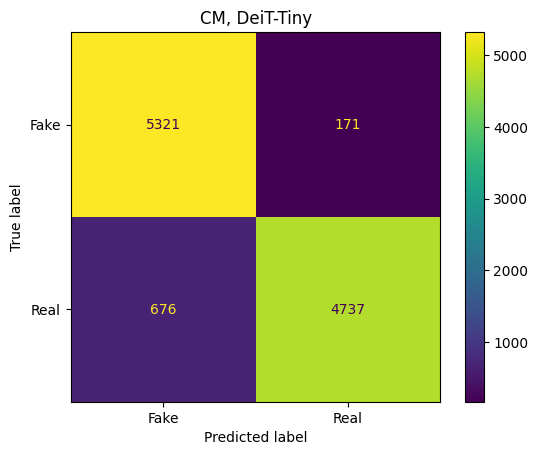

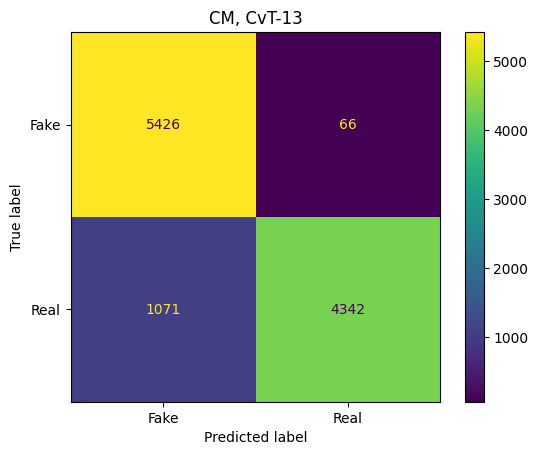

In [ ]:
############################## CONFUSION MATRICES ##############################
# https://stackoverflow.com/questions/74020233/how-to-plot-confusion-matrix-in-pytorch

# grabbing correct labels of the testing set and predictions from each model from corresponding df
cm = confusion_matrix(df_Mine["label"], df_Mine["prediction"])
ConfusionMatrixDisplay(cm, display_labels=class_names).plot()
plt.title("CM, Own Model")
plt.show()
print()
print()

cm1 = confusion_matrix(df_1["label"], df_1["prediction"])
ConfusionMatrixDisplay(cm1, display_labels=class_names).plot()
plt.title("CM, ViT_B_16")
plt.show()
print()
print()

cm2 = confusion_matrix(df_2["label"], df_2["prediction"])
ConfusionMatrixDisplay(cm2, display_labels=class_names).plot()
plt.title("CM, DeiT-Tiny")
plt.show()
print()
print()

cm3 = confusion_matrix(df_3["label"],df_3["prediction"])
ConfusionMatrixDisplay(cm3, display_labels=class_names).plot()
plt.title("CM, CvT-13")
plt.show()
print()
print()

In [ ]:
########################## MISSCLASIFICATION ANALYSIS ##########################
# https://www.datacamp.com/cheat-sheet/pandas-cheat-sheet-for-data-science-in-python

# checking for any misclassified images between the models
misclassified = ((df_Mine["correct"] == False) | (df_1["correct"] == False) | (df_2["correct"] == False) | (df_3["correct"] == False))

df_misclassified = df_Mine[misclassified].copy() #copies misclassified images info and if myvit got it correct or not, and its prediction

#https://pandas.pydata.org/docs/user_guide/dsintro.html
#Column selection, addition, deletion
# adds new column called "x"     # adds these values from the df's
# allows for side by side comparison of predictions of models where 1 or more models missclasified an image
# also displaying probabilities to compare confidence between models during misclassifications
df_misclassified["model1_prediction"] = df_1["prediction"]
df_misclassified["1_prob_fake"] = df_1["prob_fake"]
df_misclassified["1_prob_real"] = df_1["prob_real"]

df_misclassified["model2_prediction"] = df_2["prediction"]
df_misclassified["2_prob_fake"] = df_2["prob_fake"]
df_misclassified["2_prob_real"] = df_2["prob_real"]

df_misclassified["model3_prediction"] = df_3["prediction"]
df_misclassified["3_prob_fake"] = df_3["prob_fake"]
df_misclassified["3_prob_real"] = df_3["prob_real"]


#a7 for changing 0 and 1 to Fake and Real for easier readibility
label_map = {0: class_names[0], 1: class_names[1]}
# defining which columns will be changed from 0/1 to fake/real
change_column = ["label", "prediction", "model1_prediction", "model2_prediction", "model3_prediction"]

for column in change_column: #looping so columns change one after the other
    df_misclassified[column] = df_misclassified[column].map(label_map)

df_misclassified = df_misclassified.drop(columns="correct", errors="ignore") #errors stops code from crashing if column was already droppped

#saving it all to one csv for ease of compatison
comparison_checkpoint = f"{preds_checkpoints}any_misclassifications.csv"
df_misclassified.to_csv(comparison_checkpoint, index=False)

print(f"Total images: {len(df_Mine)}")
print(f"Own model missclassified images: {(df_Mine["correct"] == False).sum()}")
print(f"ViT_B_16 missclassified images: {(df_1["correct"] == False).sum()}")
print(f"DeiT-Tiny missclassified images: {(df_2["correct"] == False).sum()}")
print(f"CvT-13 missclassified images: {(df_3["correct"] == False).sum()}")
print()
print(f"Saved misclassified images to {comparison_checkpoint}")


Total images: 10905
Own model missclassified images: 1096
ViT_B_16 missclassified images: 765
DeiT-Tiny missclassified images: 847
CvT-13 missclassified images: 1137

Saved misclassified images to /content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/any_misclassifications.csv


In [ ]:
########################## SPECIFIC MISSCLASIFICATION ##########################
# ALL models misclassified the same image
all_misclassified = ((df_misclassified["prediction"] != df_misclassified["label"]) & (df_misclassified["model1_prediction"] != df_misclassified["label"])
& (df_misclassified["model2_prediction"] != df_misclassified["label"]) & (df_misclassified["model3_prediction"] != df_misclassified["label"]))

df_all_misclassified = df_misclassified[all_misclassified].copy()

#saving its own file
all_wrong_checkpoint = f"{preds_checkpoints}all_misclassified.csv"
df_all_misclassified.to_csv(all_wrong_checkpoint, index=False)

print(f"Misclassifed images by all models: {len(df_all_misclassified)}")

# OWN model misclassified, pre-trained classified correctly
pt_misclassified = ((df_misclassified["prediction"] == df_misclassified["label"]) & (df_misclassified["model1_prediction"] != df_misclassified["label"])
& (df_misclassified["model2_prediction"] != df_misclassified["label"]) & (df_misclassified["model3_prediction"] != df_misclassified["label"]))

df_pt_misclassified = df_misclassified[pt_misclassified].copy()

#saving its own file
pt_wrong_checkpoint = f"{preds_checkpoints}pt_misclassified.csv"
df_pt_misclassified.to_csv(pt_wrong_checkpoint, index=False)


print(f"Only own model got right: {len(df_pt_misclassified)}")


# PRE-TRAINED misclassified, own model classified correctly (low hope)
own_misclassified = ((df_misclassified["prediction"] != df_misclassified["label"]) & (df_misclassified["model1_prediction"] == df_misclassified["label"])
& (df_misclassified["model2_prediction"] == df_misclassified["label"]) & (df_misclassified["model3_prediction"] == df_misclassified["label"]))

df_own_misclassified = df_misclassified[own_misclassified].copy()

#saving its own file
own_wrong_checkpoint = f"{preds_checkpoints}own_misclassified.csv"
df_own_misclassified.to_csv(own_wrong_checkpoint, index=False)


print(f"Only own model got wrong: {len(df_own_misclassified)}")



Misclassifed images by all models: 138
Only own model got right: 249
Only own model got wrong: 641
